<a href="https://colab.research.google.com/github/fecheromero/CEIA-bag-repository/blob/main/AdD_ejercicio_2_Federico_Romero_ipynb_txt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de datos - Actividad individual 2

In [ ]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import describe


### Funciones auxiliares (helper functions)



In [ ]:
# Función para graficar
def plot_histograma(data, column, figsize=(6, 3), bins=15, kde=True, mvd=True, shade=True, snk=False):
    skewness = (data[column]).skew()
    kurtosis = (data[column]).kurt()
    media = (data[column]).mean()
    var = (data[column]).var()
    std = (data[column]).std()
    plt.figure(figsize=figsize)
    plt.grid(axis='y')
    sns.histplot(data[column], bins=bins, kde=kde)
    if snk:
        plt.figtext(0.7, 0.8, f'Asimetría: {skewness:.2f}', fontsize=10, color='blue')
        plt.figtext(0.715, 0.73, f'Curtosis: {kurtosis:.2f}', fontsize=10, color='blue')
        plt.axvline(media, color='red', linestyle='--', label='Media')


    # Sombreado
    if mvd and shade:
        plt.axvspan(media - std, media + std, alpha=0.1, color='orange', label='±1 Std')
        plt.axvline(media + std, color='orange', linestyle=':', label='+1 Std')
        plt.axvline(media - std, color='orange', linestyle=':', label='-1 Std')
        plt.figtext(0.15, 0.80, f'Media: {media:.2f}', fontsize=10, color='red')
        plt.figtext(0.15, 0.73, f'Var:   {var:.2f}',   fontsize=10, color='red')
        plt.figtext(0.15, 0.66, f'Std:   {std:.2f}',   fontsize=10, color='orange')



    plt.title(f'Variable: {column}')
    plt.xlabel(f'{column}')
    plt.ylabel('Frecuencia')
    plt.show()

    return

In [ ]:
def cuartiles(variable):
    Q1 = variable.quantile(0.25)
    Q2 = variable.quantile(0.50)  # Percentile 5-0 - Equivalente a la mediana
    Q3 = variable.quantile(0.75)
    return Q1, Q2, Q3

In [ ]:
def print_categorias(dataframe, columna):
    print(f"Cantidad de categorías que tiene la variable '{columna}': {dataframe[columna].nunique()}\n")
    print(f"Nombres de categorías presentes en la variable '{columna}': {dataframe[columna].unique()}\n")

    freq = dataframe[columna].value_counts()
    freq_rel = dataframe[columna].value_counts(normalize=True).mul(100).round(2)

    freq_tabla = pd.DataFrame({'Frecuencia absoluta': freq, 'Frecuencia relativa (%)': freq_rel})

    print(f"Frecuencias de cada categoría en la variable '{columna}':\n{freq_tabla}\n")

In [ ]:
def plot_pie(data, column, ax=None, startangle=90, palette='pastel', title=None):
    counts = data[column].value_counts()

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))

    ax.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=startangle,
        colors=sns.color_palette(palette)
    )
    ax.set_title(title if title else f'Distribución de "{column}"')
    ax.axis('equal') # Asegura que el gráfico sea circular

In [ ]:
def plot_frecuencias_relativas(data, column, ax=None, palette='viridis', figsize=(9, 4), title=None):
    total = len(data)
    relative_freq = data[column].value_counts() / total

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    sns.barplot(x=relative_freq.values, y=relative_freq.index, hue=relative_freq.index,
                palette=palette, ax=ax, legend=False)

    ax.set_title(title if title else f'Frecuencias relativas de {column}')
    ax.set_xlabel('Frecuencia relativa')
    ax.set_ylabel(column)

plt.show()

In [ ]:
def plot_violin_box(data, num_col, cat_col, figsize=(12, 4), palette='pastel', title=None):
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

    # Violin plot
    sns.violinplot(data=data, x=cat_col, y=num_col, hue=cat_col,
                   palette=palette, ax=axes[0], legend=False)
    axes[0].set_title(f'Violin: {num_col} vs. {cat_col}')
    axes[0].grid(axis='y', ls='--')

    # Box plot
    sns.boxplot(data=data, x=cat_col, y=num_col, hue=cat_col,
                palette=palette, ax=axes[1], legend=False)
    axes[1].set_title(f'Boxplot: {num_col} vs. {cat_col}')
    axes[1].grid(axis='y', ls='--')

    plt.suptitle(title if title else f'{num_col} vs {cat_col}', fontsize=13)
    plt.tight_layout()
    plt.show()

---
## Importamos el dataset

El dataset tiene casi 1000 datos de canciones de spotify

In [ ]:
import pandas as pd

df = pd.read_csv("hf://datasets/hassaanshafqat/spotify-data/Spotify Most Streamed Songs.csv")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


#### Primera inspección del dataset de Spotify

In [ ]:
print(f"Dimensiones del dataset: {df.shape}")
display(df.head())

Dimensiones del dataset: (953, 25)


,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,cover_url
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,B,Major,80,89,83,31,0,8,4,Not Found
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,C#,Major,71,61,74,7,0,10,4,https://i.scdn.co/image/ab67616d0000b2730656d5...
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,F,Major,51,32,53,17,0,31,6,https://i.scdn.co/image/ab67616d0000b273e85259...
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,A,Major,55,58,72,11,0,11,15,https://i.scdn.co/image/ab67616d0000b273e787cf...
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,A,Minor,65,23,80,14,63,11,6,https://i.scdn.co/image/ab67616d0000b273ab5c9c...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            953 non-null    object
 1   artist(s)_name        953 non-null    object
 2   artist_count          953 non-null    int64 
 3   released_year         953 non-null    int64 
 4   released_month        953 non-null    int64 
 5   released_day          953 non-null    int64 
 6   in_spotify_playlists  953 non-null    int64 
 7   in_spotify_charts     953 non-null    int64 
 8   streams               953 non-null    object
 9   in_apple_playlists    953 non-null    int64 
 10  in_apple_charts       953 non-null    int64 
 11  in_deezer_playlists   953 non-null    object
 12  in_deezer_charts      953 non-null    int64 
 13  in_shazam_charts      903 non-null    object
 14  bpm                   953 non-null    int64 
 15  key                   858 non-null    ob

#### Identificamos y ajustamos los tipos de variables

In [ ]:

# Pandas no necesariamente asigna el dtype en forma correcta al importar.
# Conviene revisar cada variable y asignar el tipo de dato correcto.

for col in ['streams', 'in_deezer_playlists']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(',', '', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')

if 'in_shazam_charts' in df.columns:
    df['in_shazam_charts'] = df['in_shazam_charts'].astype(str).str.replace(',', '', regex=False)
    df['in_shazam_charts'] = pd.to_numeric(df['in_shazam_charts'], errors='coerce')

spotify_numericas = [
    'artist_count', 'released_year', 'released_month', 'released_day',
    'in_spotify_playlists', 'in_spotify_charts', 'streams',
    'in_apple_playlists', 'in_apple_charts', 'in_deezer_playlists', 'in_deezer_charts',
    'in_shazam_charts', 'bpm', 'danceability_%', 'valence_%', 'energy_%',
    'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%'
]

spotify_cat_nom = [
    'key', 'mode'
]

spotify_strings = ['track_name', 'artist(s)_name', 'cover_url']

spotify_cat_ord = {}

dtype_map = {col: 'float64' for col in spotify_numericas}
dtype_map.update({col: 'category' for col in spotify_cat_nom})
dtype_map.update({col: 'string' for col in spotify_strings})
dtype_map.update(spotify_cat_ord)

for col, dtype in dtype_map.items():
    if col in df.columns:
        try:
            df[col] = df[col].astype(dtype)
        except Exception as e:
            print(f"Error converting column {col} to {dtype}: {e}")

df.dtypes

,0
track_name,string[python]
artist(s)_name,string[python]
artist_count,float64
released_year,float64
released_month,float64
released_day,float64
in_spotify_playlists,float64
in_spotify_charts,float64
streams,float64
in_apple_playlists,float64


## 1. Exploración de VARIABLES NUMÉRICAS

### 1.1. Medidas de tendencia central: media, mediana y moda


#### Media

In [ ]:
np.mean(df['streams'])    # con NumPy

np.float64(514137424.93907565)

#### Mediana

In [ ]:
np.median(df['streams'].dropna())  # con NumPy (ignorando nulos)

np.float64(290530915.0)

#### Moda

In [ ]:
df['streams'].mode()[0]     # con Pandas

np.float64(156338624.0)

### 1.2. Medidas de tendencia central + histograma




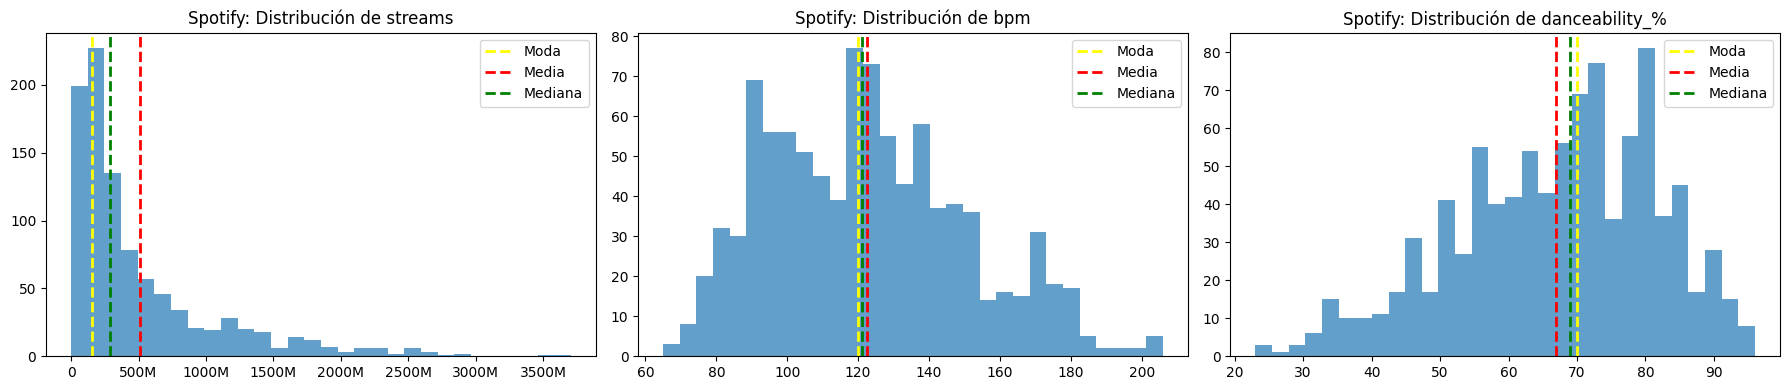

In [ ]:
import matplotlib.ticker as mtick

variables_to_plot = ['streams', 'bpm', 'danceability_%']

fig, axes = plt.subplots(1, len(variables_to_plot), figsize=(18, 4))

def thousands_formatter(x, pos):
    if x >= 1_000_000: # For millions
        return f'{int(x/1_000_000)}M'
    elif x >= 1000: # For thousands
        return f'{int(x/1000)}K'
    else: # For smaller numbers
        return f'{int(x)}'

formatter = mtick.FuncFormatter(thousands_formatter)

for i, col in enumerate(variables_to_plot):
    data = df[col].dropna()
    if not data.empty:
        ax = axes[i]
        ax.hist(data, bins=30, alpha=0.7)
        ax.axvline(data.mode()[0], color='yellow', ls='--', lw=2, label='Moda')
        ax.axvline(data.mean(), color='red', ls='--', lw=2, label='Media')
        ax.axvline(data.median(), color='green', ls='--', lw=2, label='Mediana')
        ax.set_title(f'Spotify: Distribución de {col}')
        ax.legend()

        if col in ['streams']:
            ax.xaxis.set_major_formatter(formatter)
    else:
        axes[i].set_title(f'No hay datos para {col}')
        axes[i].set_visible(False)

plt.tight_layout()
plt.show()

#### KDE

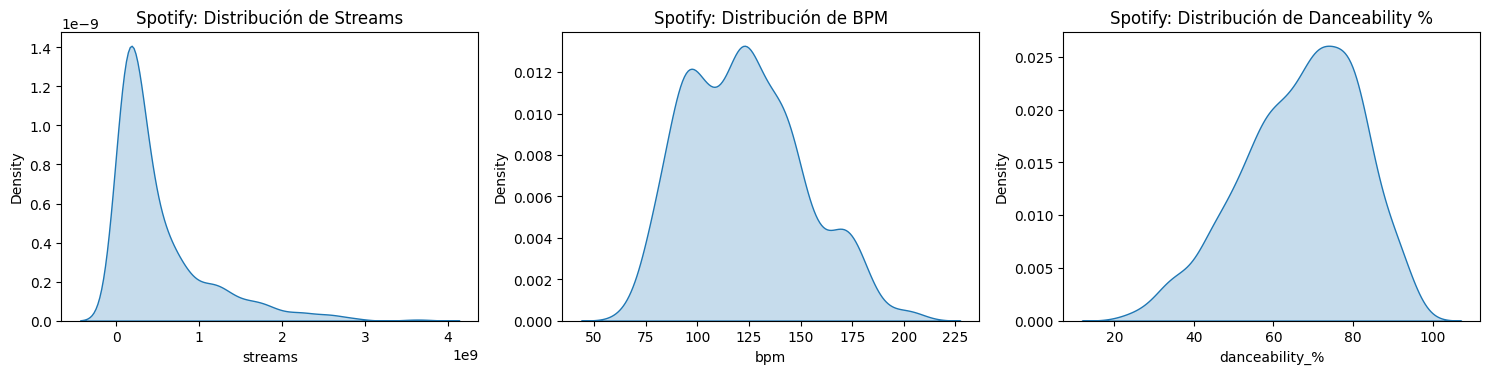

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.kdeplot(data=df, x='streams', fill=True, ax=axes[0])
sns.kdeplot(data=df, x='bpm', fill=True, ax=axes[1])
sns.kdeplot(data=df, x='danceability_%', fill=True, ax=axes[2])
axes[0].set_title('Spotify: Distribución de Streams')
axes[1].set_title('Spotify: Distribución de BPM')
axes[2].set_title('Spotify: Distribución de Danceability %')

plt.tight_layout()
plt.show()

#### Conclusiones de la Distribución de Variables Numéricas

**Observaciones Clave:**

*   **Streams:** La distribución de la cantidad de reproducciones muestra un patrón decreciente, con la mayoría de las canciones acumulando menos de 250 millones de reproducciones. Esto sugiere una fuerte concentración de streams en un grupo más pequeño de canciones.

    > *Nota:* Es importante considerar que este dataset se basa en el top de canciones de 2023, por lo que las canciones de artistas emergentes o con menor popularidad no están incluidas en este análisis.

*   **BPM (Beats Per Minute):** La media, mediana y moda de los BPMs se agrupan notablemente cerca de los 120. Este rango es comúnmente asociado con géneros como el techno y el pop, lo que es coherente con la predominancia de estos estilos en los tops musicales globales.

*   **Danceability %** Se observa una clara preferencia por canciones con altos niveles de 'danceability'  en el top 1000 de 2023. Esto indica que las canciones más exitosas en Spotify durante este período tienden a ser más bailables.

### 1.3. Cuartiles y rango intercuartil


In [ ]:
print('--- Análisis de Cuartiles ---')

for col in ['streams', 'bpm', 'danceability_%']:
    print(f'\n### Variable: {col}')
    # Drop NaN values for quartile calculation to avoid errors
    data_series = df[col].dropna()
    if not data_series.empty:
        Q1, Q2, Q3 = cuartiles(data_series)
        IQR = Q3 - Q1

        print(f'  Q1 (25%): {Q1:.2f}')
        print(f'  Q2 (Mediana, 50%): {Q2:.2f}')
        print(f'  Q3 (75%): {Q3:.2f}')
        print(f'  Rango Intercuartil (IQR): {IQR:.2f}')
    else:
        print(f'  No hay datos válidos para calcular cuartiles en {col}.')

--- Análisis de Cuartiles ---

### Variable: streams
  Q1 (25%): 141636175.00
  Q2 (Mediana, 50%): 290530915.00
  Q3 (75%): 673869022.00
  Rango Intercuartil (IQR): 532232847.00

### Variable: bpm
  Q1 (25%): 100.00
  Q2 (Mediana, 50%): 121.00
  Q3 (75%): 140.00
  Rango Intercuartil (IQR): 40.00

### Variable: danceability_%
  Q1 (25%): 57.00
  Q2 (Mediana, 50%): 69.00
  Q3 (75%): 78.00
  Rango Intercuartil (IQR): 21.00


### 1.4. Estadística descriptiva completa

In [ ]:
# Con Pandas
print("Estadística descriptiva del dataset Spotify:\n")
df.describe()

Estadística descriptiva del dataset Spotify:



,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
count,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,9.520000e+02,953.000000,953.000000,953.000000,953.000000,903.000000,953.000000,953.00000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000
mean,1.556139,2018.238195,6.033578,13.930745,5200.124869,12.009444,5.141374e+08,67.812172,51.908709,385.187828,2.666317,59.995570,122.540399,66.96957,51.431270,64.279119,27.057712,1.581322,18.213012,10.131165
std,0.893044,11.116218,3.566435,9.201949,7897.608990,19.575992,5.668569e+08,86.441493,50.630241,1130.535561,6.035599,161.161093,28.057802,14.63061,23.480632,16.550526,25.996077,8.409800,13.711223,9.912888
min,1.000000,1930.000000,1.000000,1.000000,31.000000,0.000000,2.762000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,65.000000,23.00000,4.000000,9.000000,0.000000,0.000000,3.000000,2.000000
25%,1.000000,2020.000000,3.000000,6.000000,875.000000,0.000000,1.416362e+08,13.000000,7.000000,13.000000,0.000000,0.000000,100.000000,57.00000,32.000000,53.000000,6.000000,0.000000,10.000000,4.000000
50%,1.000000,2022.000000,6.000000,13.000000,2224.000000,3.000000,2.905309e+08,34.000000,38.000000,44.000000,0.000000,2.000000,121.000000,69.00000,51.000000,66.000000,18.000000,0.000000,12.000000,6.000000
75%,2.000000,2022.000000,9.000000,22.000000,5542.000000,16.000000,6.738690e+08,88.000000,87.000000,164.000000,2.000000,37.000000,140.000000,78.00000,70.000000,77.000000,43.000000,0.000000,24.000000,11.000000
max,8.000000,2023.000000,12.000000,31.000000,52898.000000,147.000000,3.703895e+09,672.000000,275.000000,12367.000000,58.000000,1451.000000,206.000000,96.00000,97.000000,97.000000,97.000000,91.000000,97.000000,64.000000


## 2. Relaciones entre variables

<hr style="border:1px solid gray">

### 2.1. Relaciones entre variables numéricas

##### Matriz de Correlación: Mapa de Calor

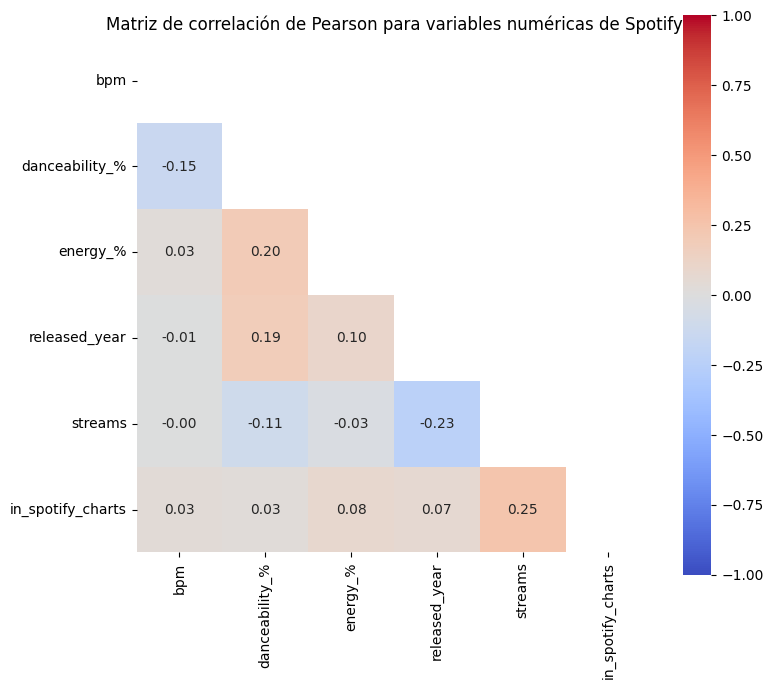

In [ ]:
# Seleccionar las columnas numéricas relevantes para el análisis de correlación
spotify_numerical_corr_cols = [
    'bpm', 'danceability_%', 'energy_%', 'released_year', 'streams', 'in_spotify_charts'
]

spotify_numerical_corr_cols = [col for col in spotify_numerical_corr_cols if col in df.columns]

corr_matrix_spotify = df[spotify_numerical_corr_cols].corr()

mask = np.triu(np.ones_like(corr_matrix_spotify, dtype=bool))

plt.figure(figsize=(8, 7))
sns.heatmap(corr_matrix_spotify, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True, mask=mask)
plt.title('Matriz de correlación de Pearson para variables numéricas de Spotify')
plt.tight_layout()
plt.show()

#### Conclusiones sobre la Relación entre Variables Numéricas

No se observa una tendencia clara hacia relaciones lineales fuertes entre las variables numéricas analizadas. Aunque, como era de esperar, la cantidad de reproducciones (`streams`) muestra una correlación con la presencia en las listas de Spotify (`in_spotify_charts`), la intensidad de esta relación no es tan estrecha como se podría haber anticipado.

---


### 2.2 Exploración de VARIABLES CATEGÓRICAS



In [ ]:
# Variable 'key'
print_categorias(df, 'key')

Cantidad de categorías que tiene la variable 'key': 11

Nombres de categorías presentes en la variable 'key': ['B', 'C#', 'F', 'A', 'D', ..., 'G#', 'G', 'E', 'A#', 'D#']
Length: 12
Categories (11, object): ['A', 'A#', 'B', 'C#', ..., 'F', 'F#', 'G', 'G#']

Frecuencias de cada categoría en la variable 'key':
     Frecuencia absoluta  Frecuencia relativa (%)
key                                              
C#                   120                    13.99
G                     96                    11.19
G#                    91                    10.61
F                     89                    10.37
D                     81                     9.44
B                     81                     9.44
A                     75                     8.74
F#                    73                     8.51
E                     62                     7.23
A#                    57                     6.64
D#                    33                     3.85



In [ ]:
# Variable 'mode'
print_categorias(df, 'mode')

Cantidad de categorías que tiene la variable 'mode': 2

Nombres de categorías presentes en la variable 'mode': ['Major', 'Minor']
Categories (2, object): ['Major', 'Minor']

Frecuencias de cada categoría en la variable 'mode':
       Frecuencia absoluta  Frecuencia relativa (%)
mode                                               
Major                  550                    57.71
Minor                  403                    42.29



### 2.3. Descripción de categóricas con la función $\texttt{describe}$

In [ ]:
df.describe(include='category')

# count = cant. de datos no nulos
# unique = cantidad de categorias distintas
# top = categoria con mayor frecuencia
# freq = frecuencia de la categoria top
# CUIDADO! en el caso multimodal, pandas elige y muestra una categoría arbitrariamente

,key,mode
count,858,953
unique,11,2
top,C#,Major
freq,120,550


/tmp/ipykernel_8010/3257063914.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_10_keys = df.groupby('key')['streams'].sum().nlargest(10).reset_index()


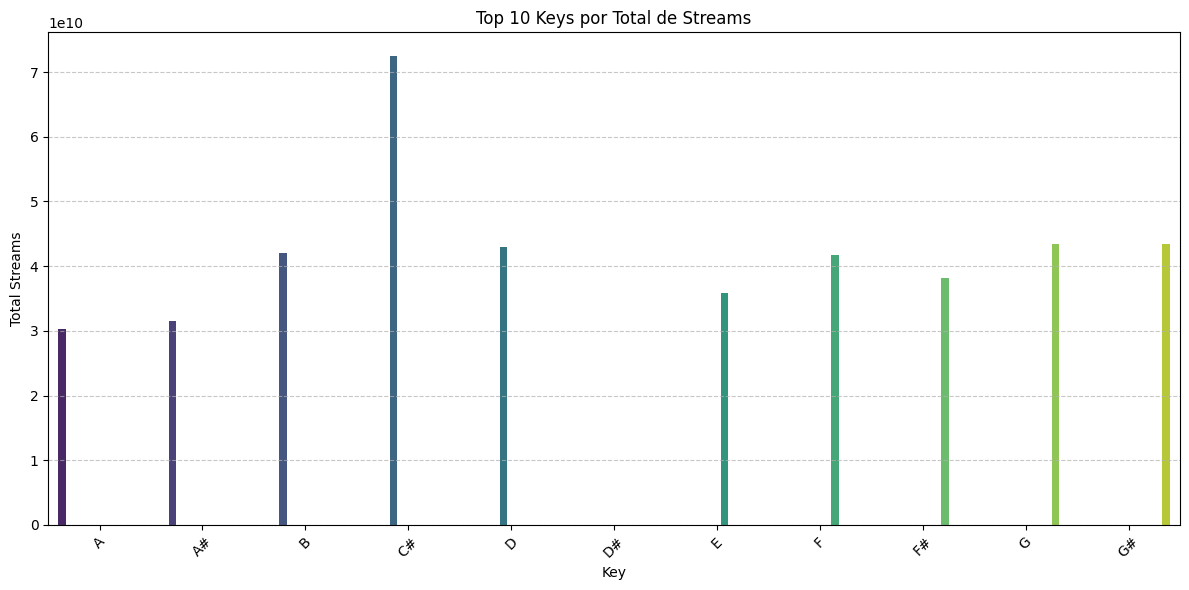

In [ ]:
# Top 10 Keys por Streams
top_10_keys = df.groupby('key')['streams'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_keys, x='key', y='streams', hue='key', palette='viridis', legend=False)
plt.title('Top 10 Keys por Total de Streams')
plt.xlabel('Key')
plt.ylabel('Total Streams')
plt.xticks(rotation=45)
plt.grid(axis='y', ls='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_8010/1535122771.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_modes = df.groupby('mode')['streams'].sum().nlargest(10).reset_index()


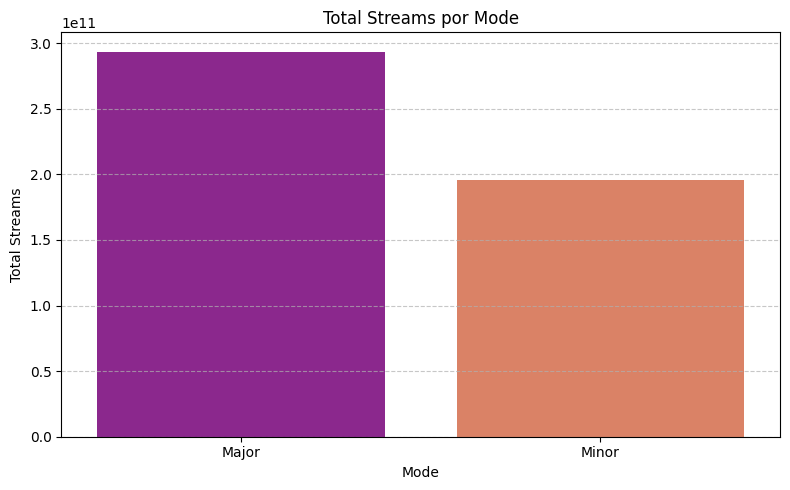

In [ ]:
top_modes = df.groupby('mode')['streams'].sum().nlargest(10).reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=top_modes, x='mode', y='streams', hue='mode', palette='plasma', legend=False)
plt.title('Total Streams por Mode')
plt.xlabel('Mode')
plt.ylabel('Total Streams')
plt.grid(axis='y', ls='--', alpha=0.7)
plt.tight_layout()
plt.show()

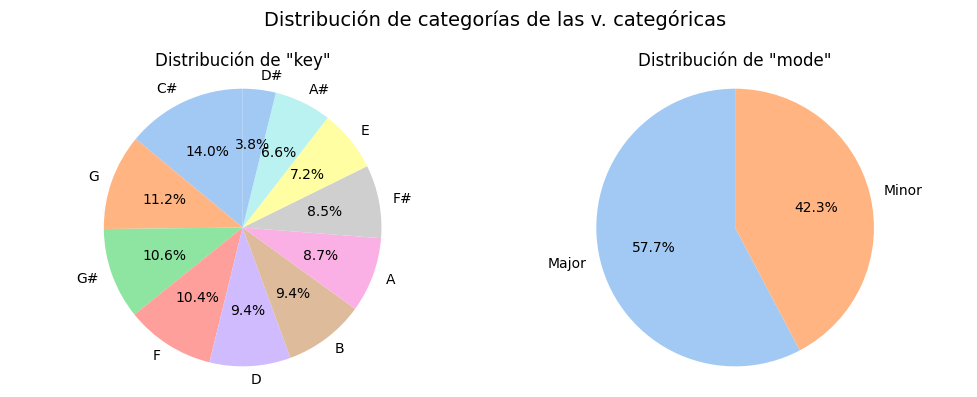

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()

for i, col in enumerate(['key', 'mode']):
    plot_pie(df, col, ax=axes[i])

plt.suptitle('Distribución de categorías de las v. categóricas', fontsize=14)
plt.tight_layout()
plt.show()

#### Conclusiones Top 10 de Key y Mode por Streams

Hay una tendencia clara hacia el uso de DO sostenido (C#) y escalas mayores en las canciones mas reproducidas.
En cuanto al uso,se vuelve mas pareja la distribución en escalas.

## 3. Otras relaciones de key y mode

### 3.1 Boxplots y violinplots

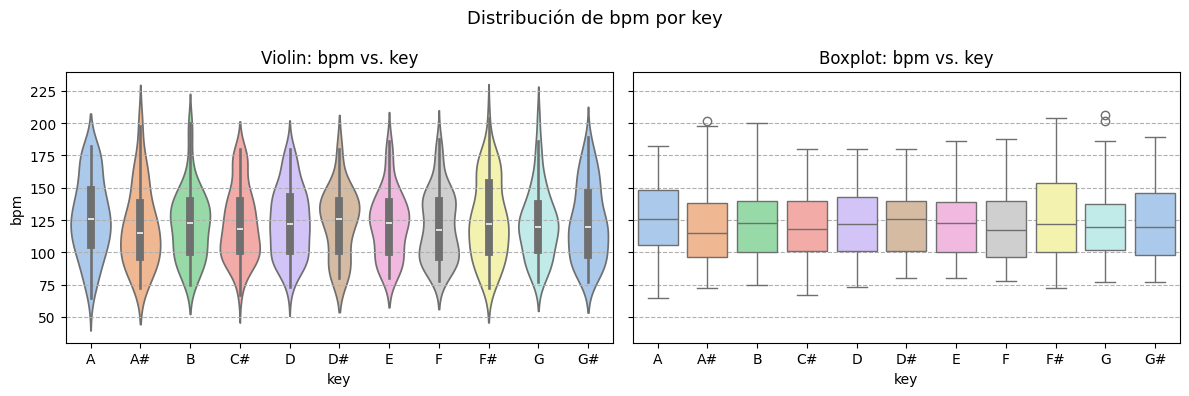

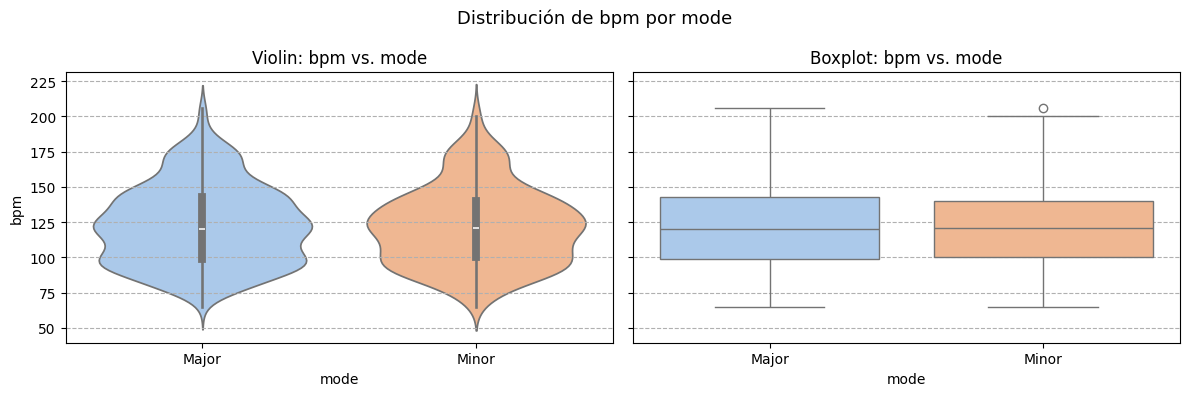

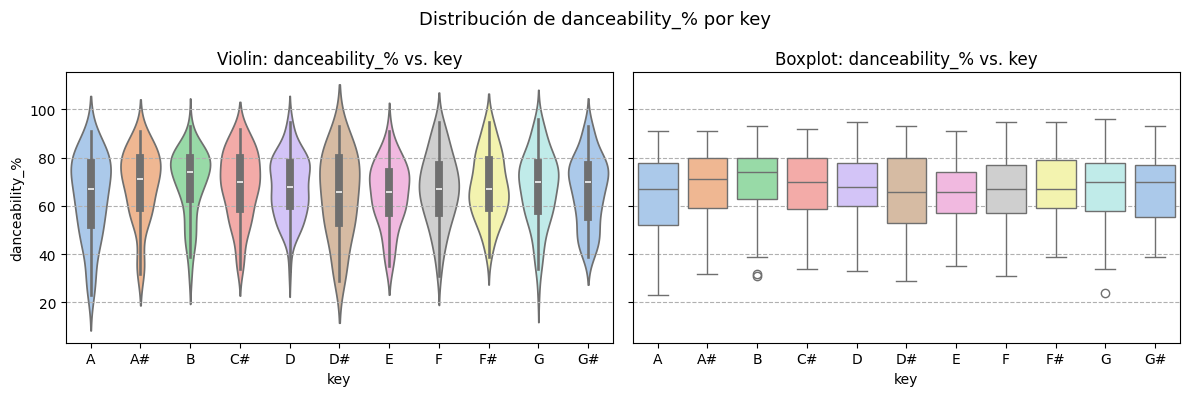

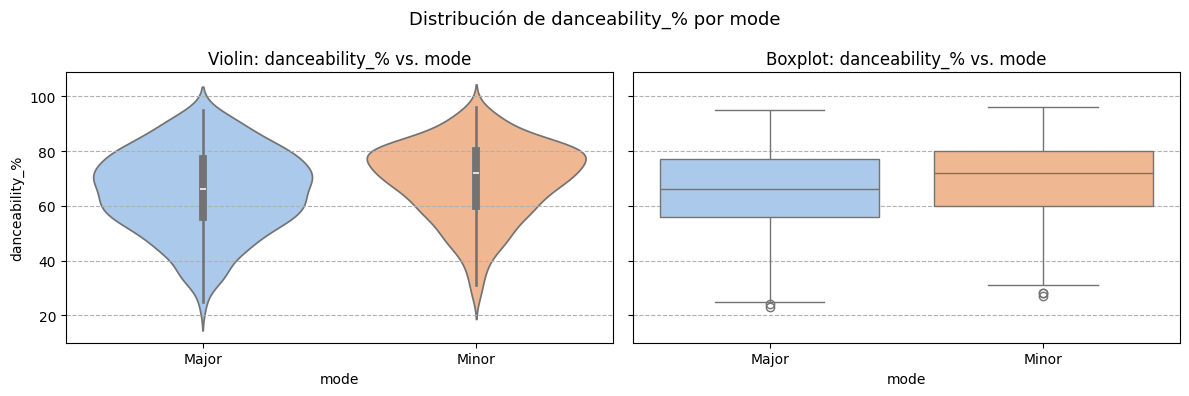

In [ ]:
cat_cols_spotify = ['key', 'mode']
num_cols_spotify = ['bpm', 'danceability_%']

for num in num_cols_spotify:
    for cat in cat_cols_spotify:
        plot_violin_box(df, num, cat, title=f'Distribución de {num} por {cat}')

### 3.2 Swarmplot de streams

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 9.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 6.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 17.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 15.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 11.0% of the points cannot be placed

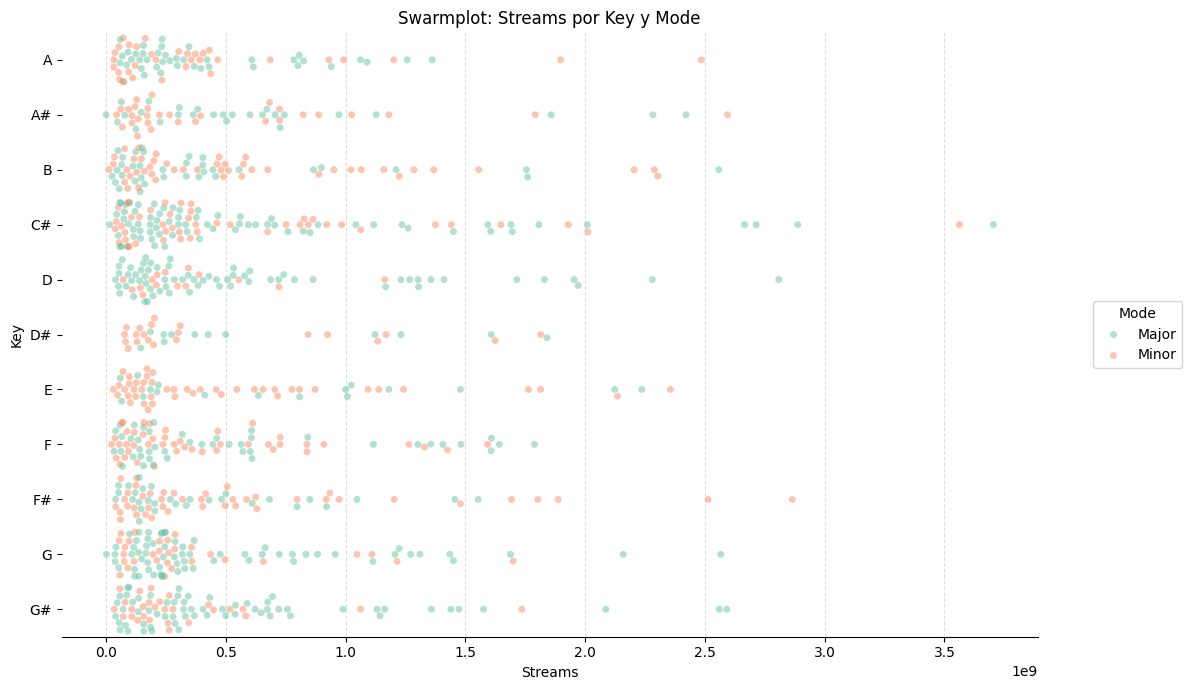

In [ ]:
plt.figure(figsize=(12, 7))
sns.swarmplot(data=df, x='streams', y='key', hue='mode', palette='Set2', alpha=0.5, size=5)
plt.title('Swarmplot: Streams por Key y Mode')
plt.xlabel('Streams')
plt.ylabel('Key')
plt.grid(axis='x', ls='--', alpha=0.4)
sns.despine(left=True)
plt.legend(title='Mode', bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.tight_layout()
plt.show()

### 3.3. Relación entre Key y la Presencia Total en Charts

In [ ]:
# Identificar las columnas relacionadas con charts
chart_columns = [
    'in_spotify_charts', 'in_apple_charts', 'in_deezer_charts', 'in_shazam_charts'
]

# Asegurarse de que todas las columnas existan en el DataFrame antes de sumarlas
chart_columns_exist = [col for col in chart_columns if col in df.columns]

# Crear la variable ficticia 'total_charts_presence' sumando las columnas de charts
df['total_charts_presence'] = df[chart_columns_exist].sum(axis=1)

print("Nueva columna 'total_charts_presence' creada y agregada al DataFrame.")
display(df[['key', 'total_charts_presence']].head())

Nueva columna 'total_charts_presence' creada y agregada al DataFrame.


,key,total_charts_presence
0,B,1246.0
1,C#,570.0
2,F,1283.0
3,A,867.0
4,A,623.0


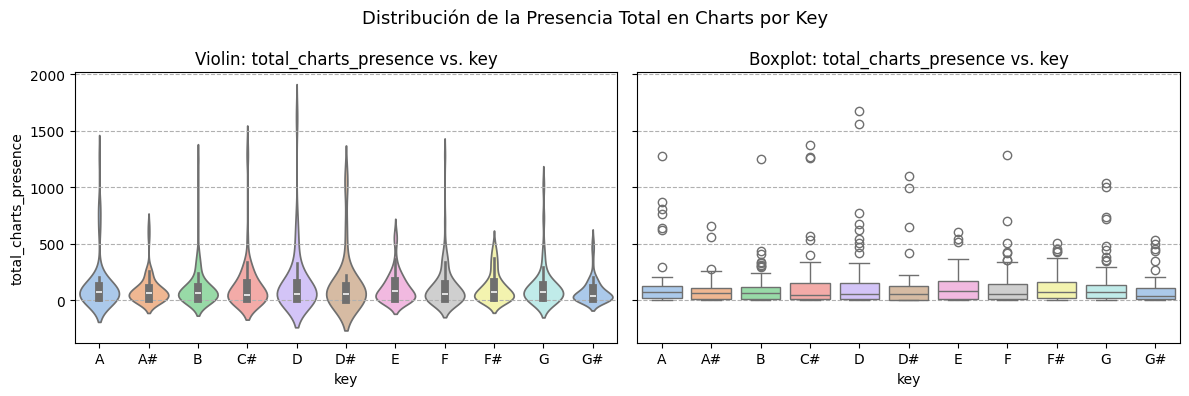

In [ ]:
# Visualizar la relación entre 'key' y 'total_charts_presence'
plot_violin_box(
    df,
    'total_charts_presence',
    'key',
    title='Distribución de la Presencia Total en Charts por Key'
)

### Conclusiones Adicionales sobre Key y Mode

*   **Relación Key, BPM y Danceability:** Aunque la escala de Do sostenido (C#) es la más recurrente en términos de reproducciones, se observa una mayor amplitud en los valores de BPM para las escalas de La (A) y Sol (G). En el análisis por 'danceability', la escala de Re sostenido (D#) muestra una mayor variabilidad.

*   **Distribución de Modos por Escala:** La distribución de los modos (Mayor/Menor) no es equitativa en todas las escalas. Específicamente, se registra una mayor prevalencia del modo menor en las escalas de Mi (E) y Fa (F).

*   **Presencia en Charts vs. Streams:** Un hallazgo notable es que, al considerar la suma de la presencia en todos los charts disponibles, la escala de Re (D) parece tener una mayor representatividad general en los rankings, a pesar de que C# es la escala con más streams directos. Esto sugiere que no siempre las canciones con más streams son las que dominan el mayor número de listas de popularidad.